# Implementation of a Variational Autoencoder (VAE) from Scratch

This notebook implements a **Variational Autoencoder (VAE)** from scratch in PyTorch.

Unlike standard Autoencoders, a VAE is a **generative model**. Instead of mapping an input $x$ to a single point in the latent space, a VAE maps it to a probability distribution (modeled as a Gaussian). This forces the latent space to be continuous and regularized, allowing us to generate realistic new data by sampling from it.

### Core Mathematical Concepts:
1. **Reparameterization Trick**: Since backpropagation cannot pass through a random sampling step, we sample $z$ as:
   $$z = \mu + \sigma \odot \epsilon \quad \text{where} \quad \epsilon \sim \mathcal{N}(0, I)$$
   This allows gradients to flow directly through $\mu$ and $\sigma$.
2. **Loss Function**: The VAE objective is to maximize the Evidence Lower Bound (ELBO), which translates to minimizing:
   $$\mathcal{L}_{\text{VAE}} = \mathcal{L}_{\text{Reconstruction}} + \mathcal{L}_{\text{KL}}$$
   where $\mathcal{L}_{\text{KL}}$ is the Kullback-Leibler divergence measuring how much the predicted distribution deviates from a standard normal prior $\mathcal{N}(0, I)$.


## 1. Imports and Setup
We import PyTorch and its neural network module, data loaders, datasets, matplotlib for plotting, and sklearn for PCA.


In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets , transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

## 2. Device Configuration
We check if a GPU is available to accelerate training, otherwise we default to CPU.


In [11]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## 3. Dataset and DataLoader
We load the classic **MNIST** dataset of handwritten digits (0-9) and prepare the PyTorch `DataLoader` with a batch size of 128.


In [12]:
BATCH_SIZE = 128

data_transform = transforms.Compose([transforms.ToTensor()])

train_dataset = datasets.MNIST(root= './data', train= True, download= True, transform= data_transform)

train_loader = DataLoader(train_dataset, batch_size= BATCH_SIZE, shuffle= True)


## 4. VAE Architecture Definition
We define the `VAE` network class.
* **Encoder**: Outputs two vectors: $\mu$ (mean) and $\log(\sigma^2)$ (log variance) representing the Gaussian distribution parameters for the input.
* **Reparameterization**: Samples $z$ using the reparameterization trick: $z = \mu + \epsilon \cdot e^{0.5 \cdot \log(\sigma^2)}$.
* **Decoder**: Maps the sample $z$ back to a 784-dimensional reconstructed image.


In [13]:
latent_dim = 128

class VAE(nn.Module):
    def __init__(self, input_dim = 784, hidden_dim = 256, latent_dim = latent_dim):
        super().__init__()

        #Encoder

        self.fc1 = nn.Linear(input_dim,hidden_dim)
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

        #Decoder

        self.fc2 = nn.Linear(latent_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, input_dim)

        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def encoder(self, x):

        h = self.relu(self.fc1(x))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):

        std = torch.exp(0.5*logvar)
        eps = torch.randn_like(std)
        z = mu + eps*std
        return z

    def decode(self, z):

        h = self.relu(self.fc2(z))
        out = self.sigmoid(self.fc3(h))
        return out

    def forward(self, x):

        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        x_reconstructed = self.decode(z)
        return x_reconstructed, mu, logvar

## 5. Loss Function Definition
The loss function consists of two parts:
1. **Reconstruction Loss**: Binary Cross Entropy (BCE) measuring how well the decoder output matches the input.
2. **KL Divergence**: Regularization term penalizing the latent distribution for deviating from the prior $\mathcal{N}(0, I)$:
   $$\mathcal{L}_{\text{KL}} = -\frac{1}{2} \sum \left(1 + \log(\sigma^2) - \mu^2 - \sigma^2 \right)$$


In [14]:
def vae_loss(recon_x, x, mu, logvar):


    bce = nn.functional.binary_cross_entropy(
        recon_x,x,reduction="sum"
    )

    # KL
    kl = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    )

    return bce + kl

## 6. Initialization
We instantiate the VAE model, place it on the target device, and define the Adam optimizer with a learning rate of $10^{-3}$.


In [15]:
model = VAE().to(device)
optimizer = optim.Adam(model.parameters(), lr= 1e-3)

## 7. Model Training Loop
We train the VAE for 15 epochs. During training, we compute the combined reconstruction and KL divergence losses, perform gradient backpropagation, and track our training loss.


In [ ]:
epochs = 15

model.train()

for epoch in range(epochs):
    total_loss = 0

    for x, _ in (train_loader):

        x =  x.view(-1, 784).to(device)

        optimizer.zero_grad()

        x_reconstructed, mu, logvar = model(x)
        loss = vae_loss(x_reconstructed, x, mu, logvar)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader.dataset)

    print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(train_loader)}")

## 8. Reconstruction Quality Assessment
We select a batch of digit images from the dataset, encode and decode them using the trained VAE, and plot the original images alongside their reconstructed counterparts.


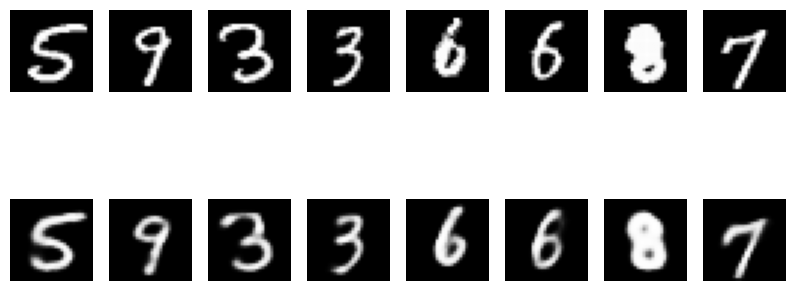

In [17]:
model.eval()

with torch.no_grad():

    x, _ = next(iter(train_loader))

    x = x.view(-1, 784).to(device);

    x_reconstructed, _, _ = model(x)

    n = 8
    plt.figure(figsize = (10, 4.5))

    for i in range(n):
        plt.subplot(2, n, i+1)
        plt.imshow(x[i].cpu().reshape(28, 28), cmap = "gray")
        plt.axis("off")

        plt.subplot(2, n, i+1+n)
        plt.imshow(x_reconstructed[i].cpu().reshape(28, 28), cmap = "gray")
        plt.axis("off")

    plt.show()

## 9. Latent Space Visualization Helper
We define a helper function `visualize_latent_space`. For VAE, we use the mean vector $\mu$ as the point representation. We project the high-dimensional latent space (128D) down to 2D using PCA.


In [20]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA


def visualize_latent_space(model, dataloader, device):
    model.eval()

    latents = []
    labels = []

    with torch.no_grad():
        for x, y in dataloader:
            x = x.view(x.size(0), -1).to(device)

            mu, logvar = model.encoder(x)  # Get both mu and logvar

            latents.append(mu.cpu())  # Use mu for latent space visualization
            labels.append(y)

    latents = torch.cat(latents, dim=0).numpy()
    labels = torch.cat(labels, dim=0).numpy()

    latent_dim = latents.shape[1]

    print(f"Latent Shape: {latents.shape}")

    # --------------------------------------------------
    # 1D Latent Space
    # --------------------------------------------------
    if latent_dim == 1:
        plt.figure(figsize=(8, 5))

        plt.hist(
            latents[:, 0],
            bins=50,
            alpha=0.8,
            edgecolor="black"
        )

        plt.title("1D Latent Distribution")
        plt.xlabel("Latent Value")
        plt.ylabel("Frequency")
        plt.show()

    # 2D Latent Space

    elif latent_dim == 2:
        plt.figure(figsize=(8, 6))

        scatter = plt.scatter(
            latents[:, 0],
            latents[:, 1],
            c=labels,
            cmap="tab10",
            s=10,
            alpha=0.7
        )

        plt.colorbar(scatter)
        plt.title("2D Latent Space")
        plt.xlabel("z1")
        plt.ylabel("z2")
        plt.show()

    # 3D Latent Space

    elif latent_dim == 3:
        fig = plt.figure(figsize=(9, 7))
        ax = fig.add_subplot(111, projection="3d")

        scatter = ax.scatter(
            latents[:, 0],
            latents[:, 1],
            latents[:, 2],
            c=labels,
            cmap="tab10",
            s=10,
            alpha=0.7
        )

        fig.colorbar(scatter)

        ax.set_title("3D Latent Space")
        ax.set_xlabel("z1")
        ax.set_ylabel("z2")
        ax.set_zlabel("z3")

        plt.show()

    # Higher Dimensions -> PCA -> 2D

    else:
        print(
            f"Latent dimension is {latent_dim}. "
            "Applying PCA → 2D..."
        )

        pca = PCA(n_components=2)
        latents_2d = pca.fit_transform(latents)

        explained = pca.explained_variance_ratio_.sum()

        plt.figure(figsize=(8, 6))

        scatter = plt.scatter(
            latents_2d[:, 0],
            latents_2d[:, 1],
            c=labels,
            cmap="tab10",
            s=10,
            alpha=0.7
        )

        plt.colorbar(scatter)

        plt.title(
            f"PCA Projection of Latent Space\n"
            f"Explained Variance: {explained:.2%}"
        )

        plt.xlabel("PC1")
        plt.ylabel("PC2")

        plt.show()

## 10. Visualizing the Learned VAE Latent Space
We execute the visualization helper. Notice how the clusters in the VAE latent space are typically more continuous and centered around the origin compared to a standard Autoencoder, thanks to the KL divergence regularization.


Latent Shape: (60000, 128)
Latent dimension is 128. Applying PCA → 2D...


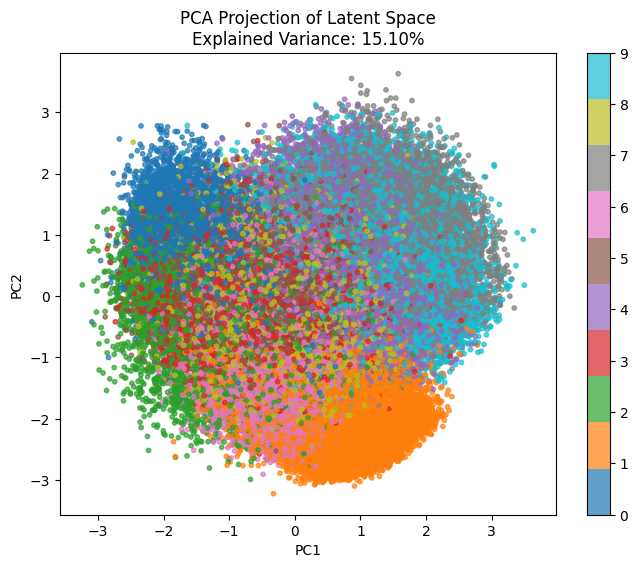

In [21]:
visualize_latent_space(
    model,
    train_loader,
    device
)

## 11. Generating New Handwritten Digits
Since the latent space is regularized, we can sample a random vector directly from $\mathcal{N}(0, I)$, feed it to the decoder, and generate a completely new, realistic handwritten digit.


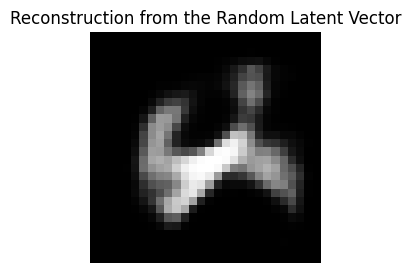

In [23]:
model.eval()

with torch.no_grad():

    latent_dim = model.fc_mu.out_features # Corrected line
    z_random = torch.randn(1, latent_dim).to(device)

    x_generated = model.decode(z_random) # Changed to model.decode

    x_generated = x_generated.cpu().view(28, 28)

plt.figure(figsize = (3,3))
plt.imshow(x_generated, cmap = "gray")
plt.axis('off')
plt.title('Reconstruction from the Random Latent Vector')
plt.show()